<a href="https://colab.research.google.com/github/ervatoker/IOT-Erva-Toker/blob/main/GRANDE_TONIoT_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CONFIG

DRIVE_DATASET = "/content/drive/MyDrive/datasets/toniot_arnob_dataset"
DRIVE_OUT_DIR = "/content/drive/MyDrive/toniot_outputs"

LABEL_COL   = "type"
RANDOM_SEED = 42
TEST_SIZE   = 0.2
VAL_SIZE    = 0.1

# GRANDE settings
N_ESTIMATORS = 512
DEPTH        = 5
EPOCHS       = 100
BATCH_SIZE   = 256

print("Config loaded.")

Config loaded.


In [2]:
# INSTALL

!pip install -q git+https://github.com/s-marton/GRANDE.git
!pip install -q scikit-learn pandas numpy matplotlib seaborn

print("All packages installed — restart runtime if prompted!")

  Preparing metadata (setup.py) ... done
All packages installed — restart runtime if prompted!


In [3]:
# IMPORTS + DRIVE MOUNT + GPU CHECK

import os, glob, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix,
    precision_score, recall_score,
    roc_auc_score, cohen_kappa_score,
    matthews_corrcoef, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

from google.colab import drive
drive.mount("/content/drive")
os.makedirs(DRIVE_OUT_DIR, exist_ok=True)

# GPU check
if not torch.cuda.is_available():
    print("WARNING: No GPU detected. GRANDE will run on CPU (much slower).")
    print("Go to Runtime -> Change runtime type -> T4 GPU -> Save")
else:
    print(f"GPU confirmed : {torch.cuda.get_device_name(0)}")
    print(f"VRAM          : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    os.environ['CUDA_VISIBLE_DEVICES'] = '0'

Mounted at /content/drive
GPU confirmed : Tesla T4
VRAM          : 15.6 GB


In [4]:
# LOAD DATA

csv_files = glob.glob(os.path.join(DRIVE_DATASET, "**/*.csv"), recursive=True)
print(f"Found {len(csv_files)} CSV files")

dfs = []
for f in csv_files:
    try:
        dfs.append(pd.read_csv(f, low_memory=False))
    except Exception as e:
        print(f"  Skipped {f}: {e}")

df = pd.concat(dfs, ignore_index=True)
print(f"Total rows   : {len(df):,}")
print(f"Total columns: {df.shape[1]}")
print(f"\nLabel distribution:\n{df[LABEL_COL].value_counts()}")

Found 1 CSV files
Total rows   : 211,043
Total columns: 44

Label distribution:
type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
scanning      20000
ransomware    20000
xss           20000
mitm           1043
Name: count, dtype: int64


In [5]:
# PREPROCESS

# Drop label + non-feature columns
drop_cols = [LABEL_COL]
for col in ["ts", "src_ip", "dst_ip", "src_mac", "dst_mac"]:
    if col in df.columns:
        drop_cols.append(col)

X = df.drop(columns=drop_cols)
y_raw = df[LABEL_COL]

# Encode string labels to integers
le = LabelEncoder()
y = le.fit_transform(y_raw)
num_classes = len(le.classes_)
print(f"Classes ({num_classes}): {list(le.classes_)}")

# Keep numeric features only + replace inf
X = X.select_dtypes(include=[np.number])
X = X.replace([np.inf, -np.inf], np.nan)
print(f"Features     : {X.shape[1]}")

# Split FIRST  70 / 10 / 20  before any imputation or scaling
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv,
    test_size=VAL_SIZE / (1 - TEST_SIZE),
    random_state=RANDOM_SEED,
    stratify=y_tv
)
print(f"\nTrain : {len(X_train):,}")
print(f"Val   : {len(X_val):,}")
print(f"Test  : {len(X_test):,}")

# Impute NaN using TRAIN median only (no data leakage)
train_median = X_train.median()
X_train = X_train.fillna(train_median)
X_val   = X_val.fillna(train_median)
X_test  = X_test.fillna(train_median)


scaler    = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_val_s   = pd.DataFrame(scaler.transform(X_val),   columns=X_val.columns)
X_test_s  = pd.DataFrame(scaler.transform(X_test),  columns=X_test.columns)

n_features = X_train_s.shape[1]
print(f"\nFeatures after preprocessing : {n_features}")
print("Preprocessing complete — no data leakage")

Classes (10): ['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'ransomware', 'scanning', 'xss']
Features     : 17

Train : 147,729
Val   : 21,105
Test  : 42,209

Features after preprocessing : 17
Preprocessing complete — no data leakage


In [6]:
# EVALUATION HELPER

def evaluate(model_name, y_true, y_pred, label_names, out_dir):
    acc         = accuracy_score(y_true, y_pred)
    f1_macro    = f1_score(y_true, y_pred, average="macro",    zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"\n{'='*55}")
    print(f"  {model_name} — Results")
    print(f"{'='*55}")
    print(f"  Accuracy      : {acc:.4f}")
    print(f"  F1 (macro)    : {f1_macro:.4f}")
    print(f"  F1 (weighted) : {f1_weighted:.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=label_names, zero_division=0)}")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f"{model_name} — Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    path = os.path.join(out_dir, f"{model_name.lower().replace(' ', '_')}_cm.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"Saved: {path}")

    return {
        "model": model_name,
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted
    }

print("Evaluation helper ready.")

Evaluation helper ready.


In [7]:
# GRANDE TRAINING


from GRANDE import GRANDE

# Convert labels to pandas Series for GRANDE compatibility
y_train_s = pd.Series(y_train).reset_index(drop=True)
y_val_s   = pd.Series(y_val).reset_index(drop=True)
y_test_s  = pd.Series(y_test).reset_index(drop=True)

# Reset index on DataFrames
X_train_s = X_train_s.reset_index(drop=True)
X_val_s   = X_val_s.reset_index(drop=True)
X_test_s  = X_test_s.reset_index(drop=True)

params = {
    'depth': DEPTH,
    'n_estimators': N_ESTIMATORS,

    'learning_rate_weights': 0.001,
    'learning_rate_index': 0.01,
    'learning_rate_values': 0.05,
    'learning_rate_leaf': 0.05,

    'use_category_embeddings': False,
    'use_numeric_embeddings': False,

    'dropout': 0.2,
    'selected_variables': 0.8,
    'data_subset_fraction': 1.0,
    'bootstrap': False,
    'missing_values': False,

    'optimizer': 'adam',
    'cosine_decay_restarts': False,
    'reduce_on_plateau_scheduler': True,
    'label_smoothing': 0.0,
    'use_class_weights': False,
    'focal_loss': False,
    'swa': False,

    'epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
    'early_stopping_epochs': 25,
    'es_metric': True,

    'use_freq_enc': False,
    'use_robust_scale_smoothing': False,

    'problem_type': 'multiclass',
    'random_seed': RANDOM_SEED,
    'verbose': 2,
}

model = GRANDE(params=params)

print("Training GRANDE on TON-IoT...")
print(f"Config: n_estimators={N_ESTIMATORS}, depth={DEPTH}, "
      f"epochs={EPOCHS}, batch_size={BATCH_SIZE}")
print()

t0 = time.time()

model.fit(
    X=X_train_s, y=y_train_s,
    X_val=X_val_s, y_val=y_val_s
)

train_time = time.time() - t0
print(f"\nGRANDE training complete in {train_time:.1f}s ({train_time/60:.1f} min)")

Training GRANDE on TON-IoT...
Config: n_estimators=512, depth=5, epochs=100, batch_size=256



W0329 16:51:46.197000 2161 torch/_inductor/utils.py:1250] [0/0] Not enough SMs to use max_autotune_gemm mode


Epoch 001 | TrainLoss: 0.3766 | ValLoss: 0.1397 | ValAcc: 0.9593 | ValAUC: 0.9947 | ValF1: 0.8700 | Time: 39.47s
Epoch 002 | TrainLoss: 0.1271 | ValLoss: 0.1104 | ValAcc: 0.9665 | ValAUC: 0.9955 | ValF1: 0.8893 | Time: 5.79s
Epoch 003 | TrainLoss: 0.1066 | ValLoss: 0.0983 | ValAcc: 0.9715 | ValAUC: 0.9965 | ValF1: 0.9083 | Time: 5.73s
Epoch 004 | TrainLoss: 0.0978 | ValLoss: 0.0877 | ValAcc: 0.9740 | ValAUC: 0.9964 | ValF1: 0.9170 | Time: 5.47s
Epoch 005 | TrainLoss: 0.0929 | ValLoss: 0.0852 | ValAcc: 0.9768 | ValAUC: 0.9967 | ValF1: 0.9313 | Time: 5.94s
Epoch 006 | TrainLoss: 0.0917 | ValLoss: 0.0899 | ValAcc: 0.9722 | ValAUC: 0.9966 | ValF1: 0.9254 | Time: 5.79s
[EarlyStop TRAINING] no improve (1/25). best=0.085227, curr=0.089863
Epoch 007 | TrainLoss: 0.0898 | ValLoss: 0.0842 | ValAcc: 0.9740 | ValAUC: 0.9968 | ValF1: 0.9351 | Time: 5.91s
Epoch 008 | TrainLoss: 0.0884 | ValLoss: 0.0812 | ValAcc: 0.9775 | ValAUC: 0.9966 | ValF1: 0.9360 | Time: 5.72s
Epoch 009 | TrainLoss: 0.0883 | Va

Inference time : 4.02s for 42,209 samples
                (0.0953 ms per sample)

  GRANDE — Results
  Accuracy      : 0.9787
  F1 (macro)    : 0.9465
  F1 (weighted) : 0.9791

              precision    recall  f1-score   support

    backdoor       1.00      1.00      1.00      4000
        ddos       0.96      0.95      0.96      4000
         dos       1.00      0.97      0.98      4000
   injection       0.95      0.93      0.94      4000
        mitm       0.57      0.81      0.67       209
      normal       1.00      1.00      1.00     10000
    password       0.99      0.98      0.99      4000
  ransomware       0.99      1.00      1.00      4000
    scanning       0.98      0.99      0.99      4000
         xss       0.93      0.96      0.95      4000

    accuracy                           0.98     42209
   macro avg       0.94      0.96      0.95     42209
weighted avg       0.98      0.98      0.98     42209



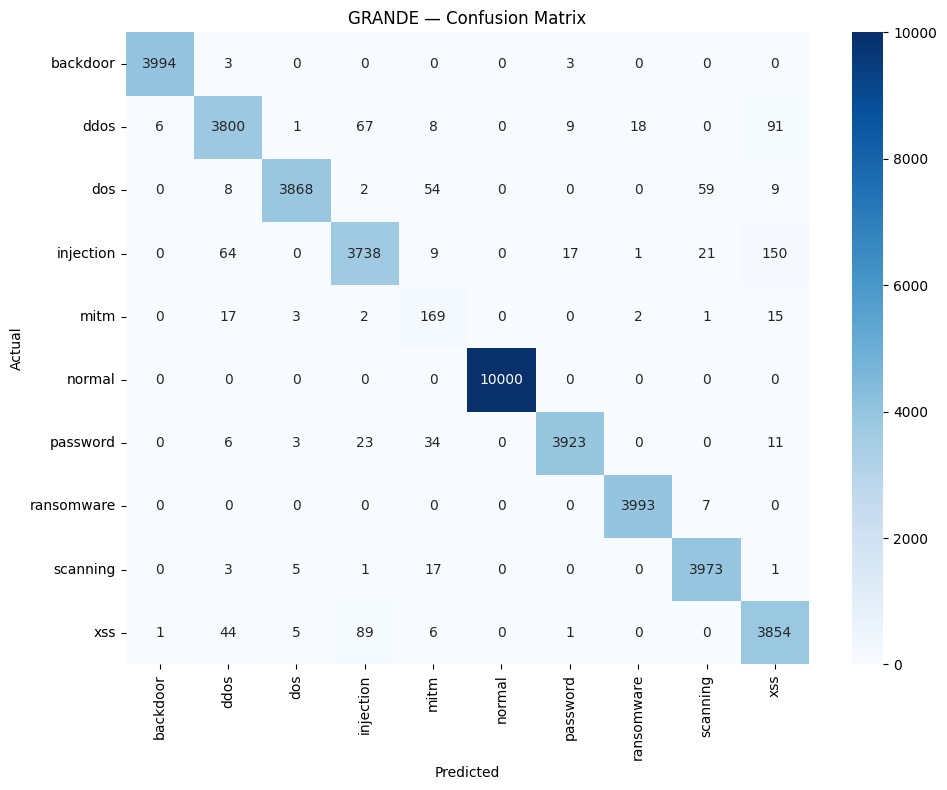

Saved: /content/drive/MyDrive/toniot_outputs/grande_cm.png


In [8]:
# GRANDE TEST EVALUATION

t0 = time.time()

grande_proba = model.predict_proba(X_test_s)
grande_preds = np.argmax(grande_proba, axis=1)

infer_time = time.time() - t0

print(f"Inference time : {infer_time:.2f}s for {len(X_test_s):,} samples")
print(f"                ({infer_time / len(X_test_s) * 1000:.4f} ms per sample)")

grande_results = evaluate(
    "GRANDE", y_test, grande_preds,
    label_names=list(le.classes_),
    out_dir=DRIVE_OUT_DIR
)

  TABLE 1: Overall Evaluation Metrics
           Metric  Score
         Accuracy 0.9787
Precision (macro) 0.9378
   Recall (macro) 0.9594
       F1 (macro) 0.9465
    F1 (weighted) 0.9791
              MCC 0.9757
    Cohen's Kappa 0.9756
  ROC-AUC (macro) 0.9988



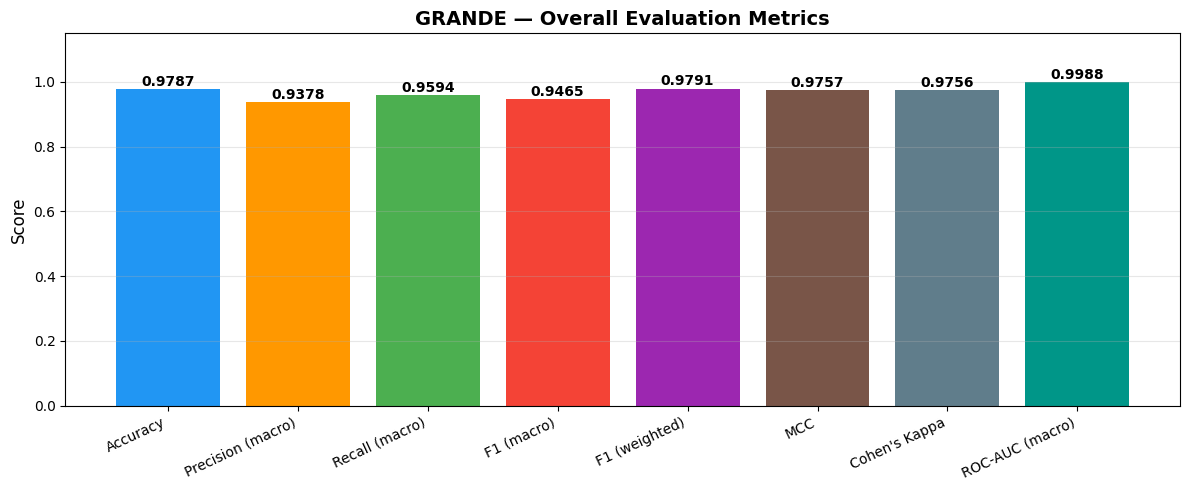

  TABLE 2: Per-Class Precision / Recall / F1
     Class  Precision  Recall  F1-Score  Support
  backdoor     0.9983  0.9985    0.9984     4000
      ddos     0.9632  0.9500    0.9566     4000
       dos     0.9956  0.9670    0.9811     4000
 injection     0.9531  0.9345    0.9437     4000
      mitm     0.5690  0.8086    0.6680      209
    normal     1.0000  1.0000    1.0000    10000
  password     0.9924  0.9808    0.9865     4000
ransomware     0.9948  0.9982    0.9965     4000
  scanning     0.9783  0.9932    0.9857     4000
       xss     0.9329  0.9635    0.9480     4000



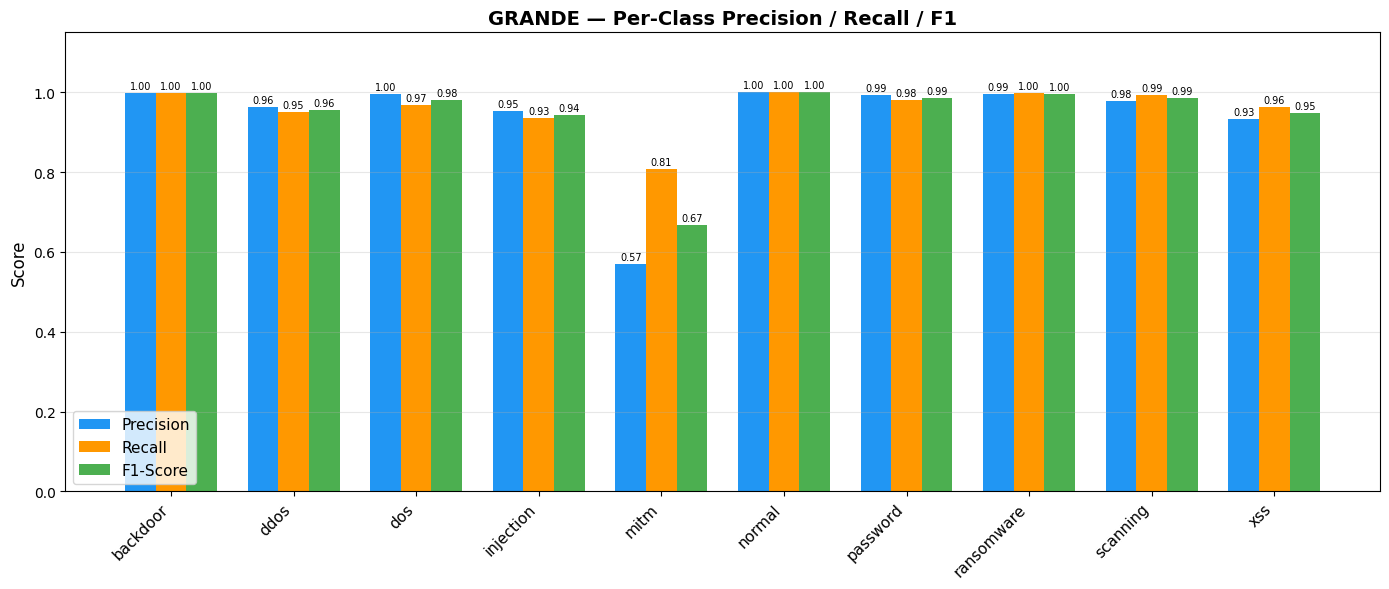

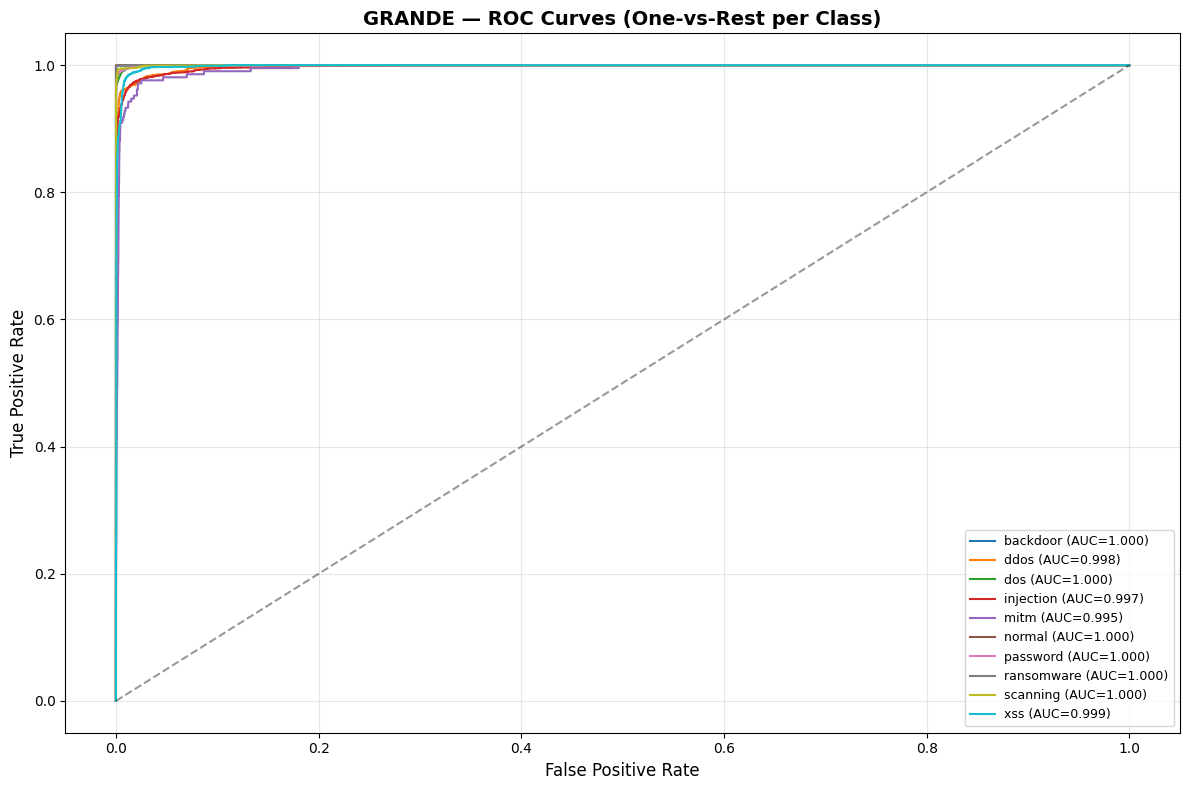

  TABLE 3: Per-Class ROC-AUC
     Class  ROC-AUC
  backdoor   1.0000
      ddos   0.9978
       dos   0.9998
 injection   0.9975
      mitm   0.9954
    normal   1.0000
  password   0.9996
ransomware   1.0000
  scanning   0.9998
       xss   0.9986

  Macro-average ROC-AUC: 0.9988

  TABLE 4: MCC & Cohen's Kappa Interpretation
                                Metric  Score Interpretation
MCC (Matthews Correlation Coefficient) 0.9757      Excellent
                         Cohen's Kappa 0.9756 Almost Perfect


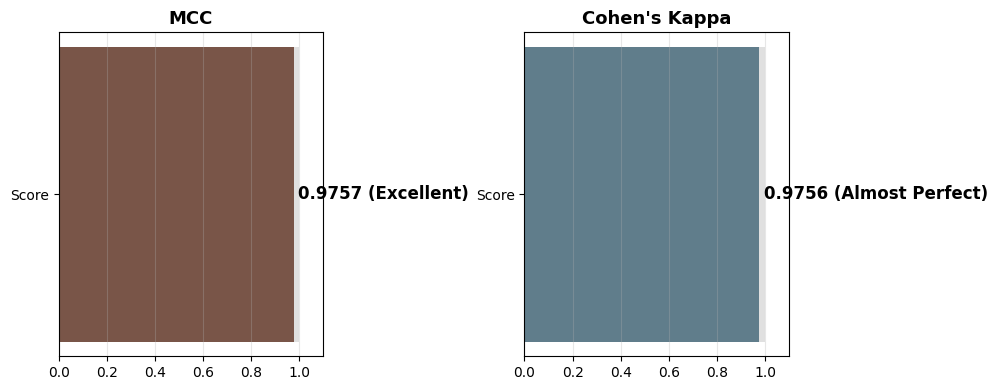

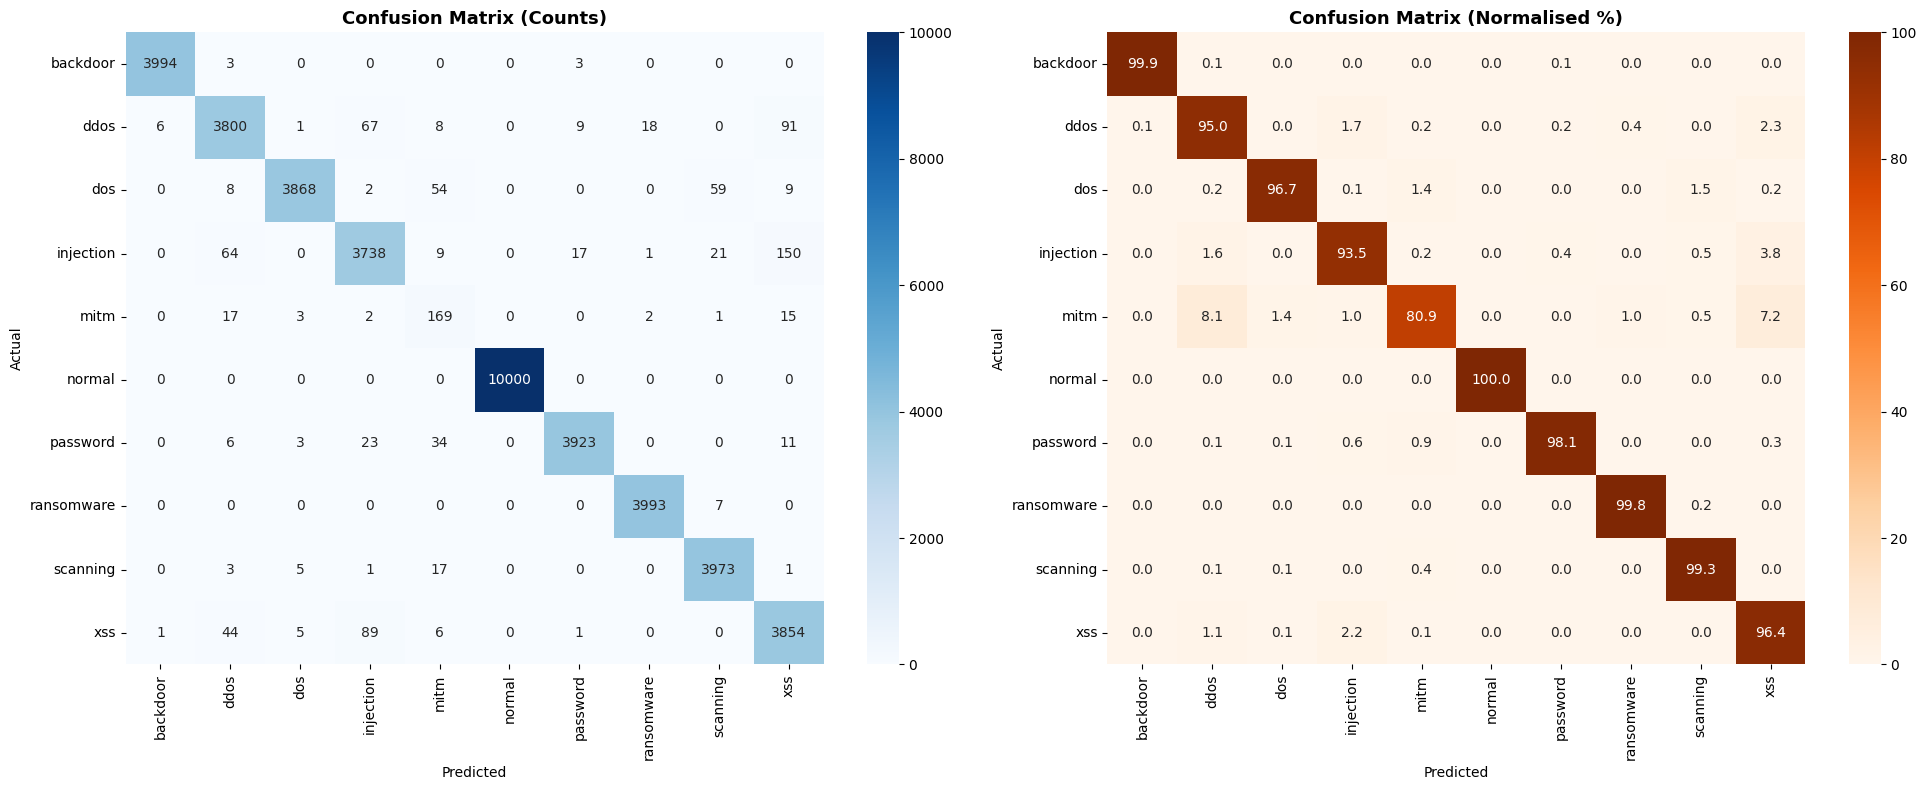


All visualisations saved to: /content/drive/MyDrive/toniot_outputs


In [9]:
# COMPREHENSIVE METRICS WITH TABLES & VISUALISATIONS

y_true = y_test
y_pred = grande_preds
y_prob = grande_proba   # already collected in Cell 8

label_names = list(le.classes_)


# 1. MACRO METRICS SUMMARY TABLE + BAR CHART

acc         = accuracy_score(y_true, y_pred)
prec_macro  = precision_score(y_true, y_pred, average="macro", zero_division=0)
rec_macro   = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1_macro    = f1_score(y_true, y_pred, average="macro", zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)
mcc         = matthews_corrcoef(y_true, y_pred)
kappa       = cohen_kappa_score(y_true, y_pred)

try:
    roc_auc = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
except:
    roc_auc = None

macro_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (macro)", "Recall (macro)",
               "F1 (macro)", "F1 (weighted)", "MCC", "Cohen's Kappa",
               "ROC-AUC (macro)"],
    "Score": [acc, prec_macro, rec_macro, f1_macro, f1_weighted,
              mcc, kappa, roc_auc if roc_auc else float('nan')]
})
macro_df["Score"] = macro_df["Score"].round(4)

print("=" * 60)
print("  TABLE 1: Overall Evaluation Metrics")
print("=" * 60)
print(macro_df.to_string(index=False))
print()

# Bar chart
fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#2196F3", "#FF9800", "#4CAF50", "#F44336",
          "#9C27B0", "#795548", "#607D8B", "#009688"]
valid = macro_df.dropna()
bars = ax.bar(valid["Metric"], valid["Score"], color=colors[:len(valid)])
for bar, val in zip(bars, valid["Score"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.4f}", ha="center", fontsize=10, fontweight="bold")
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("GRANDE — Overall Evaluation Metrics", fontsize=14, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "grande_macro_metrics.png"), dpi=150)
plt.show()


# 2. PER-CLASS PRECISION, RECALL, F1 TABLE + CHART

prec_per = precision_score(y_true, y_pred, average=None, zero_division=0)
rec_per  = recall_score(y_true, y_pred, average=None, zero_division=0)
f1_per   = f1_score(y_true, y_pred, average=None, zero_division=0)

perclass_df = pd.DataFrame({
    "Class": label_names,
    "Precision": np.round(prec_per, 4),
    "Recall": np.round(rec_per, 4),
    "F1-Score": np.round(f1_per, 4),
    "Support": [np.sum(y_true == c) for c in range(num_classes)]
})

print("=" * 60)
print("  TABLE 2: Per-Class Precision / Recall / F1")
print("=" * 60)
print(perclass_df.to_string(index=False))
print()

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(label_names))
w = 0.25
b1 = ax.bar(x - w, prec_per, w, label="Precision", color="#2196F3")
b2 = ax.bar(x,     rec_per,  w, label="Recall",    color="#FF9800")
b3 = ax.bar(x + w, f1_per,   w, label="F1-Score",  color="#4CAF50")
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0.01:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                    f"{h:.2f}", ha="center", fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(label_names, rotation=45, ha="right", fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("GRANDE — Per-Class Precision / Recall / F1", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "grande_perclass_prf.png"), dpi=150)
plt.show()


# 3. ROC-AUC PER CLASS — TABLE + CURVES

y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

auc_per_class = []
fig, ax = plt.subplots(figsize=(12, 8))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    class_auc = auc(fpr, tpr)
    auc_per_class.append(class_auc)
    ax.plot(fpr, tpr, label=f"{label_names[i]} (AUC={class_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("GRANDE — ROC Curves (One-vs-Rest per Class)", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "grande_roc_curves.png"), dpi=150)
plt.show()

roc_df = pd.DataFrame({
    "Class": label_names,
    "ROC-AUC": np.round(auc_per_class, 4)
})
print("=" * 60)
print("  TABLE 3: Per-Class ROC-AUC")
print("=" * 60)
print(roc_df.to_string(index=False))
if roc_auc:
    print(f"\n  Macro-average ROC-AUC: {roc_auc:.4f}")


# 4. MCC & COHEN'S KAPPA — INTERPRETATION TABLE + VISUAL

def interpret_mcc(val):
    if val >= 0.9: return "Excellent"
    if val >= 0.7: return "Strong"
    if val >= 0.5: return "Moderate"
    if val >= 0.3: return "Weak"
    return "Poor"

def interpret_kappa(val):
    if val >= 0.81: return "Almost Perfect"
    if val >= 0.61: return "Substantial"
    if val >= 0.41: return "Moderate"
    if val >= 0.21: return "Fair"
    return "Slight/Poor"

agreement_df = pd.DataFrame({
    "Metric": ["MCC (Matthews Correlation Coefficient)",
               "Cohen's Kappa"],
    "Score": [round(mcc, 4), round(kappa, 4)],
    "Interpretation": [interpret_mcc(mcc), interpret_kappa(kappa)]
})

print()
print("=" * 60)
print("  TABLE 4: MCC & Cohen's Kappa Interpretation")
print("=" * 60)
print(agreement_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, metric_name, value, interp, color in [
    (axes[0], "MCC", mcc, interpret_mcc(mcc), "#795548"),
    (axes[1], "Cohen's Kappa", kappa, interpret_kappa(kappa), "#607D8B"),
]:
    ax.barh(["Score"], [value], color=color, height=0.4)
    ax.barh(["Score"], [1.0], color="#E0E0E0", height=0.4, zorder=0)
    ax.set_xlim(0, 1.1)
    ax.text(value + 0.02, 0, f"{value:.4f} ({interp})",
            va="center", fontsize=12, fontweight="bold")
    ax.set_title(metric_name, fontsize=13, fontweight="bold")
    ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "grande_mcc_kappa.png"), dpi=150)
plt.show()


# 5. DUAL CONFUSION MATRIX (COUNTS + NORMALISED %)

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names, ax=axes[0])
axes[0].set_title("Confusion Matrix (Counts)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_norm, annot=True, fmt=".1f", cmap="Oranges",
            xticklabels=label_names, yticklabels=label_names, ax=axes[1])
axes[1].set_title("Confusion Matrix (Normalised %)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "grande_cm_dual.png"), dpi=150)
plt.show()

print("\nAll visualisations saved to:", DRIVE_OUT_DIR)

In [10]:
# OVERFITTING / UNDERFITTING

grande_train_proba = model.predict_proba(X_train_s)
grande_train_preds = np.argmax(grande_train_proba, axis=1)
grande_train_acc   = accuracy_score(y_train, grande_train_preds)
grande_train_f1    = f1_score(y_train, grande_train_preds, average="macro", zero_division=0)

print("=" * 50)
print("GRANDE — Train vs Test Diagnosis")
print("=" * 50)
print(f"  Train Acc    : {grande_train_acc:.4f}")
print(f"  Test  Acc    : {grande_results['accuracy']:.4f}")
print(f"  Train F1     : {grande_train_f1:.4f}")
print(f"  Test  F1     : {grande_results['f1_macro']:.4f}")
print()

acc_gap = grande_train_acc - grande_results['accuracy']
if acc_gap > 0.05:
    print(f"  Warning: Generalisation gap: {acc_gap:.4f} — possible overfitting")
elif grande_results['accuracy'] < 0.80:
    print("  Warning: Low test accuracy — possible underfitting")
else:
    print(f"  Generalisation gap: {acc_gap:.4f} — model generalises well")

print(f"\n  Training time : {train_time:.1f}s")
print(f"  Inference time: {infer_time:.2f}s ({len(X_test_s):,} samples)")

GRANDE — Train vs Test Diagnosis
  Train Acc    : 0.9786
  Test  Acc    : 0.9787
  Train F1     : 0.9449
  Test  F1     : 0.9465

  Generalisation gap: -0.0002 — model generalises well

  Training time : 412.7s
  Inference time: 4.02s (42,209 samples)


In [11]:
# SAVE RESULTS

results_df = pd.DataFrame([{
    "model"           : "GRANDE",
    "paper"           : "ICLR 2024 — Marton et al.",
    "dataset"         : "TON-IoT Network",
    "train_samples"   : len(X_train),
    "test_samples"    : len(X_test),
    "n_features"      : n_features,
    "n_classes"       : num_classes,
    "accuracy"        : acc,
    "f1_macro"        : f1_macro,
    "f1_weighted"     : f1_weighted,
    "precision_macro" : prec_macro,
    "recall_macro"    : rec_macro,
    "mcc"             : mcc,
    "cohen_kappa"     : kappa,
    "roc_auc_macro"   : roc_auc,
    "train_acc"       : grande_train_acc,
    "train_f1"        : grande_train_f1,
    "train_time_s"    : round(train_time, 2),
    "infer_time_s"    : round(infer_time, 4),
}])

csv_path = os.path.join(DRIVE_OUT_DIR, "grande_toniot_results.csv")
results_df.to_csv(csv_path, index=False)

print("\n========== FINAL RESULTS ==========")
print(results_df.T.to_string())
print(f"\nResults saved to: {csv_path}")


========== FINAL RESULTS ==========
                                         0
model                               GRANDE
paper            ICLR 2024 — Marton et al.
dataset                    TON-IoT Network
train_samples                       147729
test_samples                         42209
n_features                              17
n_classes                               10
accuracy                          0.978749
f1_macro                           0.94645
f1_weighted                       0.979073
precision_macro                   0.937768
recall_macro                      0.959436
mcc                               0.975651
cohen_kappa                       0.975634
roc_auc_macro                     0.998835
train_acc                         0.978562
train_f1                          0.944869
train_time_s                        412.67
infer_time_s                        4.0232

Results saved to: /content/drive/MyDrive/toniot_outputs/grande_toniot_results.csv
